## Fingerprint Methods

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from   scipy.special import legendre


Text(0, 0.5, '$\\Delta T$')

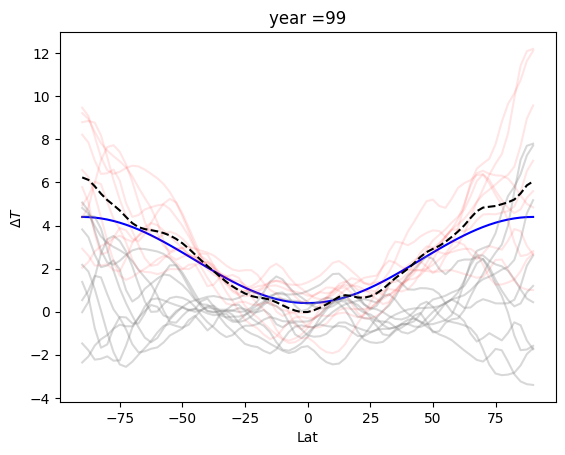

In [14]:

# using Legendre to create climate change signals
# Define the order of the Legendre polynomial
lat   = np.linspace(-90,90,73)

# Generate x values
x     = np.sin(lat/180*np.pi) # Legendre polynomials are defined on [-1, 1]

# Compute the Legendre polynomial of order n
ens_total       = 10
y_signal        = np.matrix(1.1-np.cos(lat/180*np.pi)**2).T    # signal's meridional structure is 2nd-order Legendre Polynomial
nt              = np.matrix(np.linspace(1,4,100))              # temperature increase 4K/century
noise           = np.zeros((ens_total,73,100))                 # noise has dimension of ens X year X time
signal          = (y_signal.dot(nt))                           # signal has dimension of year X time
noise_amp       = 1

for ens in range(ens_total):
    for n in range(2,40):
        P_n       = legendre(n)  # Returns a callable polynomial
        W         = np.matrix(np.random.normal(0,6/(n+1)*noise_amp,100))
        y_noise   = np.matrix(P_n(x)).T
        noise[ens,:,:] = noise[ens,:,:] + y_noise.dot(W)


year =99
plt.figure()
plt.plot(lat,signal[:,year],label ='2nd Lengdre Polynomial as noise',color='b')
plt.plot(lat,noise[:,:,year].T,'gray',alpha=0.3)
plt.plot(lat,noise[:,:,year].T+signal[:,year],color='r',alpha=0.1)
plt.plot(lat,(noise[:,:,year].T+signal[:,year]).mean(axis=1),'k--')
plt.title('year ='+str(year))
plt.xlabel('Lat')
plt.ylabel(r'$\Delta T$')





## Calculating the Time Series of Signals

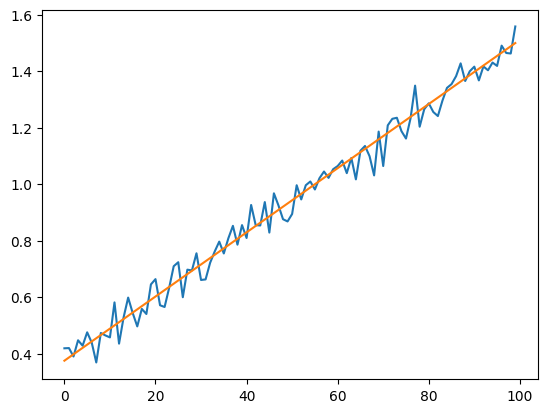

In [15]:
T         = np.array(signal)+noise     # create Temperature data
T_ens     = T.mean(axis=0)             # ensemble mean
T_ens_lat = (T_ens*(np.cos(lat/180*np.pi)**0.5)[:,np.newaxis]).mean(axis=0) # weighted by latitude
T_ens_lat_truth = (np.array(signal)*(np.cos(lat/180*np.pi)**0.5)[:,np.newaxis]).mean(axis=0) # ground truth

plt.figure()
plt.plot(T_ens_lat,label='Estimated Trend')
plt.plot(T_ens_lat_truth,label='Actual Trend')


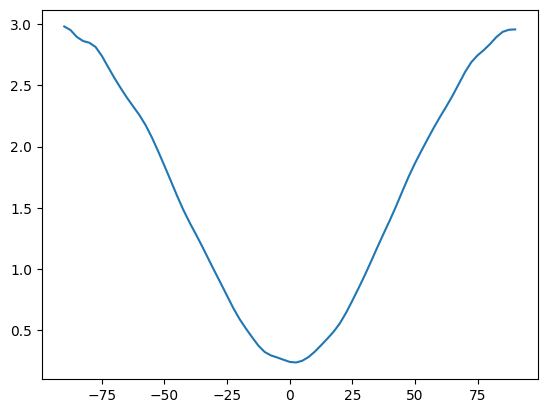

In [16]:
# assume we only have data T, (ensemble mean = T_ens_lat)
# regress T with global mean temperature, T_ens_lat
t_length  = 100
T_ens_lat = np.matrix(T_ens_lat)
T_regress = T_ens[:,:t_length].dot(T_ens_lat[:,:t_length].T).dot(np.linalg.inv(T_ens_lat[:,:t_length].dot(T_ens_lat[:,:t_length].T)))

plt.figure()
plt.plot(lat, T_regress)

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


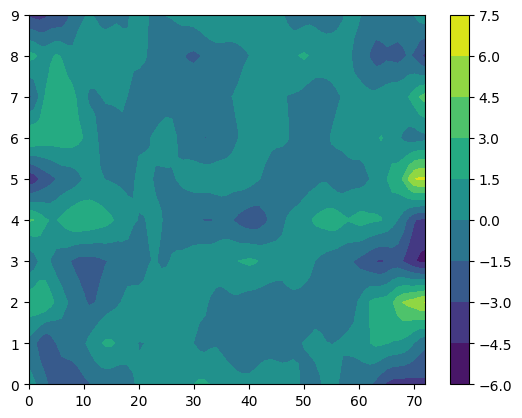

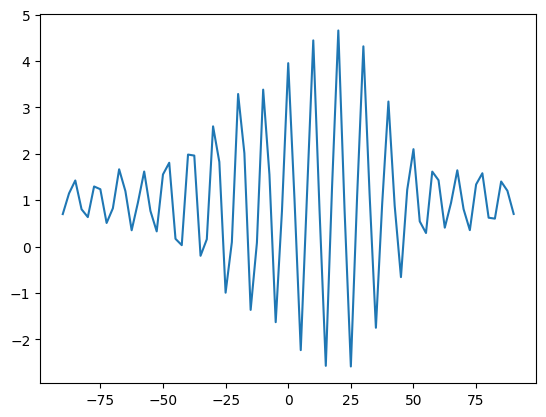

In [17]:
# Calculating the total variance
T           = T.reshape([ens_total,73,100])
T_cov       = np.zeros((73,73))
T_cov_noise = np.zeros((73,73))

for t in range(100):
    # calculate total T covariance
    T_tmp       = T[:,:,t]
    T_cov       = (T_tmp.T.dot(T_tmp)+T_cov*t)/(t+1)
    # calculate dispersion part
    T_tmp       = T[:,:,t] - T[:,:,t].mean(axis=0)
    T_cov_noise = (T_tmp.T.dot(T_tmp)+T_cov_noise*t)/(t+1)

STR = T_cov.dot(np.linalg.inv(T_cov_noise))

plt.figure()
cs  = plt.contourf(T_tmp)
plt.colorbar(cs)
v,m = np.linalg.eig(np.linalg.pinv(T_cov_noise))
idx = v.argsort()[::-1]
m   = m[:,idx]

plt.figure()
plt.plot(lat,m[:,0]*12+1)

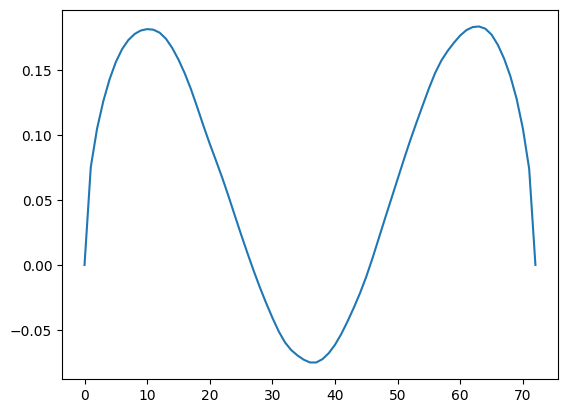

In [18]:
## dimension reduction to get rid of singularity

from sklearn.decomposition import PCA
T_tmp     = np.einsum('ijk->jik',T)
T_tmp     = T_tmp.reshape([73, ens_total*100])
T_tmp     = (np.cos(lat/180*np.pi)**0.5)[:,np.newaxis]*T_tmp
T_tmp_cov = T_tmp.dot(T_tmp.T)

pca       = PCA(n_components=10)           # reduce lat_size = 73 ---> PC_size = 10
pca.fit(T_tmp_cov)
V         = pca.components_                # V is EOF
pca_score = pca.explained_variance_ratio_  # explained variance
PCs       = V.dot(T_tmp)                   # PCs
plt.figure()
plt.plot(V[0,:])
# plt.figure()
# plt.plot(PCs[0,:].reshape([ens_total,100]).T)

/tmp/ipython-input-2432598091.py:17: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 3 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(cs)


<Figure size 640x480 with 0 Axes>

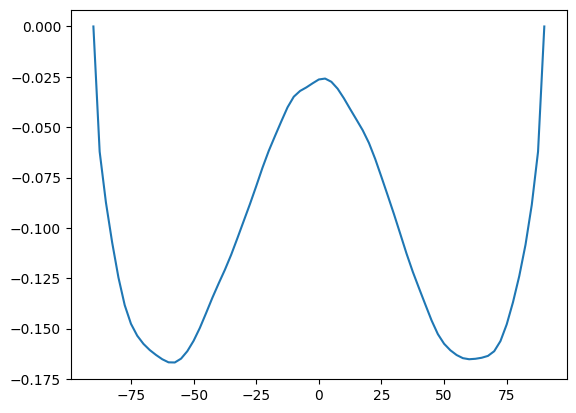

In [19]:
# Calculating the total variance
# T           = T.reshape([ens_total,73,100])
T_cov       = np.zeros((10,10))
T_cov_noise = np.zeros((10,10))
PCs         = PCs.reshape([10,ens_total,100])
PCs_tmp     = np.einsum('ijk->jik',PCs)

for t in range(100):
    # calculate total T covariance
    T_tmp       = PCs_tmp[:,:,t]
    T_cov       = (T_tmp.T.dot(T_tmp)+T_cov*t)/(t+1)
    # calculate noise covariance
    T_tmp       = PCs_tmp[:,:,t] - PCs_tmp[:,:,t].mean(axis=0)
    T_cov_noise = (T_tmp.T.dot(T_tmp)+T_cov_noise*t)/(t+1)

STNR = T_cov.dot(np.linalg.inv(T_cov_noise)) # signal to noise ratio
plt.colorbar(cs)
v,m = np.linalg.eig(STNR)
idx = v.argsort()[::-1]
m   = m[:,idx]

plt.figure()
plt.plot(lat,-V.T.dot(m[:,0]))
